In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage

load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [13]:
class TripDetails(BaseModel):
    origin: str | None = Field(default=None, description="Source or origin of the trip")

    destination: str | None = Field(default=None, description="Destination of the trip")

    battery_percentage_on_departure: int | None = Field(
        default=None,
        ge=0,
        le=100,
        description="Battery percentage of the car at departure",
    )

    is_round_trip: bool | None = Field(
        default=None, description="Whether the trip is a round trip"
    )

class LLMMessage(BaseModel):
    message: str

In [14]:
# state
class TripState(TypedDict):
    trip: TripDetails
    messages: list
    trip_ready: bool

In [15]:

structured_llm_1 = llm.with_structured_output(TripDetails)
structured_llm_2 = llm.with_structured_output(LLMMessage)

In [16]:
def gather_trip_details(state: TripState):

    prompt = f"""
        Extract the trip details from the conversation.
        If the user's response is ambiguous or unclear, do not extract the information.
        Do not overwrite existing values with `None`. Preserve previously collected information unless the user explicitly changes it.

        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

    """
    trip_details = structured_llm_1.invoke(prompt)

    return {"trip": trip_details}


def conversation_agent(state: TripState):

    prompt = f"""
        You are an intelligent EV trip-planning assistant.
        
        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

        
        Have a natural conversation with the user.

        If any required trip information is missing, ask the user, but only one question at a time.

        If the user has not decided where to go, help them decide.

        If the user's response is ambiguous or unclear, ask a follow-up question to clarify before proceeding. Do not make assumptions.

        Do not mention internal fields or technical details.
        Do not answer anything unrelated to EV trip planning.

    """

    response = structured_llm_2.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}

def validate_trip(state: TripState):

    trip = state["trip"]

    trip_ready = all(
        [
            trip.origin is not None,
            trip.destination is not None,
            trip.battery_percentage_on_departure is not None,
            trip.is_round_trip is not None,
        ]
    )

    return {"trip_ready": trip_ready}


def route_after_validation(state: TripState) -> Literal["conversation_agent", END]:

    if state["trip_ready"]:
        return END

    return "conversation_agent"

In [17]:
graph = StateGraph(TripState)

graph.add_node("gather_trip_details", gather_trip_details)
graph.add_node("conversation_agent", conversation_agent)
graph.add_node("validate_trip", validate_trip)

In [18]:
graph.add_edge(START, "gather_trip_details")
graph.add_edge("gather_trip_details", "validate_trip")
graph.add_conditional_edges("validate_trip", route_after_validation)
graph.add_edge("conversation_agent", END)

In [19]:
app = graph.compile()


In [20]:
state = {"trip": TripDetails(), "messages": [], "trip_ready": False}

# while True:

#     user_input = input("\nYou: ")

#     if user_input.lower() in ["exit", "quit"]:
#         break

#     state["messages"].append(HumanMessage(content=user_input))

#     state = app.invoke(state)

#     ai_message = state["messages"][-1]

#     print(f"AI: {ai_message.content}")

#     if state["trip_ready"]:
#         print("\nTrip details collected.")
#         print(state["trip"])
#         break

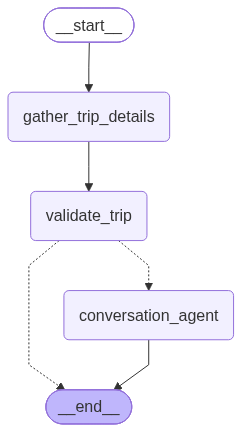

In [21]:
app